In [1]:
from utils_00 import *
# exec(open('c00_utils.py').read())

pn.extension()  # 启用 Jupyter 支持
pd.set_option('expand_frame_repr', False)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', 100)

In [2]:
native_exchange_data_dir = os.path.join(base_dir, "Native_Exchange_Data")
temporary_experimental_data_dir = os.path.join(base_dir, "Temporary_Experimental_Data")
pro = ts.pro_api(secret_dict['tushare']['api_key'])

def get_exchange_variety_map():
    # 交易所日历路径 NED_dimension_exchange_calendar_path
    NED_dimension_exchange_calendar_path = os.path.join(native_exchange_data_dir, 'dimension_exchange_calendar.csv')
    dimension_exchange_calendar = pd.read_csv(NED_dimension_exchange_calendar_path, dtype = {'date': str})

    # 获取 交易所-品种 表单
    exchange_list = [col for col in dimension_exchange_calendar.columns if col != 'date'] # 交易所列表
    map_list = []
    for exchange in exchange_list:

        exchange_variety_map = pd.DataFrame()
        for attempt in range(3):
            try:
                exchange_variety_map = pro.fut_basic(exchange = exchange, fut_type = "1", fields = ["fut_code"])
                break
            except Exception as e:
                print(f"第 {attempt + 1} 次获取 {exchange} 品种信息失败: {e}")

        exchange_variety_map = exchange_variety_map.drop_duplicates()
        exchange_variety_map["exchange"] = exchange
        map_list.append(exchange_variety_map)

    exchange_variety_map = pd.concat(map_list, ignore_index = True)
    exchange_variety_map = exchange_variety_map.groupby('exchange')['fut_code'].apply(list)
    exchange_variety_map = exchange_variety_map.to_dict()
    return exchange_variety_map

if __name__ == '__main__':
    exchange_variety_map = get_exchange_variety_map()
    exchange_variety_map.pop("CZCE")
    exchange_variety_map.pop("DCE")
    print(exchange_variety_map)

{'CFFEX': ['T', 'TF', 'IF', 'IM', 'IC', 'IH', 'TS', 'TL'], 'GFEX': ['LC', 'SI', 'PS', 'PD', 'PT'], 'INE': ['NR', 'SC', 'LU', 'BC', 'SCTAS', 'EC'], 'SHFE': ['AO', 'NI', 'AL', 'HC', 'BU', 'RU', 'FU', 'CU', 'AG', 'ZN', 'AU', 'PB', 'SS', 'RB', 'SN', 'WR', 'SP', 'BR', 'AD', 'OP']}


In [3]:
exchange = None
variety = None

if __name__ == '__main__':
    # 交易所选择组件
    exchange_radio = widgets.RadioButtons(
        options = list(exchange_variety_map.keys()),
        description = '交易所选择 exchange:',
        layout = {'width': '400px'}
    )

    # 品种选择组件（初始禁用）
    species_toggle = widgets.ToggleButtons(
        options = [],
        description = '品种选择 variety:',
        disabled = True,
        button_style = '',
        style = {'button_width': 'auto'},
        layout = widgets.Layout(width = '600px'),
    )

    # 输出提示区域
    out = widgets.Textarea(
        value = '请先选择交易所，然后选择品种',
        layout = {'width': '400px', 'height': '50px'},
        disabled = True
    )

    display(widgets.VBox([exchange_radio, species_toggle, out]))

    def on_exchange_change(change):
        """当交易所改变时，更新可选品种"""
        global exchange
        if change['name'] == 'value':
            exchange = change['new']
            varieties = exchange_variety_map.get(exchange, [])
            species_toggle.options = sorted(varieties)
            species_toggle.disabled = len(varieties) == 0
            if varieties:
                species_toggle.value = varieties[0]  # 默认选第一个
                out.value = f'已选择交易所：{exchange}，请选择品种'
            else:
                out.value = f'交易所 {exchange} 无可用品种'

    def on_species_change(change):
        """当品种改变时，记录到全局变量"""
        global variety
        if change['name'] == 'value' and species_toggle.options:
            variety = change['new']
            out.value = f'已选择交易所 exchange: {exchange}\n已选择品种 variety: {variety}'

    # 绑定事件 ["SCTAS", "SI", "FU", "AU", "SS", "WR"]
    exchange_radio.observe(on_exchange_change, names = 'value')
    species_toggle.observe(on_species_change, names = 'value')

In [4]:
dataset_range_boundary = ""  # 选择的时间范围边界字符串

if __name__ == '__main__':

    # 临时实验数据品种文件夹路径 TED_variety_path
    TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))
    dataset_range = os.listdir(TED_variety_path)
    dataset_range = sorted(dataset_range)

    dataset_range_buttons = []  # 创建数据集范围边界按钮容器
    for range_file in dataset_range:  # 为每个范围文件创建按钮
        btn = widgets.Button(
            description = range_file,
            layout = {'width': '530px', 'height': '25px'},  # 宽度较大以显示完整文件名
            button_style = ''
        )
        dataset_range_buttons.append(btn)

    dataset_range_button_column = widgets.VBox(dataset_range_buttons) # Horizontal Box & Vertical Box

    # 输出显示区域
    range_display_output = widgets.Textarea(
        value = 'dataset_range_boundary: 未选择',
        layout = {'width': '530px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([
        widgets.Label('数据集范围边界 dataset_range_boundary:'),
        dataset_range_button_column,
        range_display_output
    ]))

    def update_range_display():
        """更新显示区域"""
        global dataset_range_boundary
        range_display_output.value = f'dataset_range_boundary: {dataset_range_boundary}'

    def set_dataset_range_boundary(range_file):
        """设置数据集范围边界"""
        global dataset_range_boundary
        dataset_range_boundary = range_file
        update_range_display()

    # 事件处理函数
    def on_dataset_range_button_click(btn):
        """数据集范围按钮 点击事件"""
        set_dataset_range_boundary(btn.description)

    # 绑定事件
    for btn in dataset_range_buttons:
        btn.on_click(on_dataset_range_button_click)

    # 初始化
    update_range_display()

In [5]:
tick_granularity = 0  # 采样颗粒度 全局变量
resample_axis = None  # 采样轴 全局变量

if __name__ == '__main__':

    # 创建 tick_granularity 输入框组件
    tick_granularity_input = widgets.IntText(
        value = 0,
        description = 'tick_granularity:',
        layout = {'width': '250px', 'height': '25px'},
        style = {'description_width': '90px'},
        continuous_update = False
    )

    # 创建 tick_granularity 按钮容器
    granularity_buttons = []
    for i in [i for i in range(0, 181, 15)]:
        btn = widgets.Button(
            description = str(i),
            layout = {'width': '45px', 'height': '25px'}
        )
        btn.value = i
        granularity_buttons.append(btn)
    granularity_button_row = widgets.HBox(granularity_buttons)

    # tick_granularity 输出显示区域
    granularity_out = widgets.Textarea(
        value = '当前 tick_granularity: 0',
        layout = {'width': '400px', 'height': '30px'},
        disabled = True
    )

    # 创建 resample_axis 按钮
    axis_buttons = []
    axis_options = ['time_axis_data', 'volume_axis_data', 'money_axis_data']  # 重采样刻度选项
    for option in axis_options:
        btn = widgets.Button(
            description = option,
            layout = {'width': '135px', 'height': '25px'}
        )
        btn.value = option
        axis_buttons.append(btn)
    axis_button_row = widgets.HBox(axis_buttons)

    # resample_axis 显示区域
    axis_out = widgets.Textarea(
        value = '当前 resample_axis: None',
        layout = {'width': '400px', 'height': '30px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([tick_granularity_input, granularity_button_row, granularity_out, axis_button_row, axis_out]))

    def update_display(value):
        """更新显示"""
        global tick_granularity
        tick_granularity = value
        granularity_out.value = f'当前 tick_granularity: {tick_granularity}'
        tick_granularity_input.value = value

    def update_axis_display(value):
        """更新 resample_axis 显示"""
        global resample_axis
        resample_axis = value
        axis_out.value = f'当前 resample_axis: {resample_axis}'

    def on_input_change(change):
        """当输入框值改变时"""
        if change['name'] == 'value':
            new_value = change['new']
            if 0 <= new_value <= 600:
                update_display(new_value)
            else:
                tick_granularity_input.value = tick_granularity  # 恢复原值

    def on_button_click(btn):
        """当按钮点击时"""
        new_value = btn.value
        update_display(new_value)

    def on_axis_button_click(btn):
        """当 resample_axis 按钮点击时"""
        new_value = btn.value
        update_axis_display(new_value)

    # 绑定输入框事件
    tick_granularity_input.observe(on_input_change, names ='value')

    # 绑定所有按钮事件
    for btn in granularity_buttons:
        btn.on_click(on_button_click)

    # 绑定 resample_axis 按钮事件
    for btn in axis_buttons:
        btn.on_click(on_axis_button_click)

In [6]:
lookback_months = 0  # 回溯月份数 全局变量
split_index = None  # 切割点 index 全局变量
split_time_str = None  # 切割时间字符串 全局变量

if __name__ == '__main__':

    TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))  # 临时实验数据品种文件夹路径 TED_variety_path
    dataset_range_boundary_path = os.path.join(TED_variety_path, dataset_range_boundary)  # 时间范围文件夹路径 dataset_range_boundary_path
    tick_granularity_resample_path = os.path.join(dataset_range_boundary_path, f'tick_granularity_{tick_granularity}')  # 采样刻度文件路径 tick_granularity_resample_path
    resample_axis_data_path = os.path.join(tick_granularity_resample_path, resample_axis)  # 驱动轴数据文件路径 resample_axis_data_path

    tick_type_dict = {
        'time_axis_data': 'Nrow',
        'volume_axis_data': 'volume',
        'money_axis_data': 'money'
    }
    if resample_axis in tick_type_dict.keys():
        tick_type = tick_type_dict[resample_axis]
    else: raise ValueError

    # 主力片段拼接重采样时间索引路径 main_continuous_resampled_date_index_path
    main_continuous_resampled_date_index_path = os.path.join(resample_axis_data_path, rf"main_continuous_{tick_type}_date_index.csv")
    main_continuous_resampled_date_index = pd.read_csv(main_continuous_resampled_date_index_path, dtype = {'date': str})

    # 创建 lookback_months 输入框组件
    lookback_months_input = widgets.IntText(
        value = 0,
        description = 'lookback_months:',
        layout = {'width': '250px', 'height': '25px'},
        style = {'description_width': '100px'},
        continuous_update = False
    )

    # 创建 lookback_months 按钮容器（1~24）
    months_buttons = []
    for i in range(1, 25):
        btn = widgets.Button(
            description = str(i),
            layout = {'width': '45px', 'height': '25px'}
        )
        btn.value = i
        months_buttons.append(btn)
    first_row = widgets.HBox(months_buttons[:12])   # 前12个按钮
    second_row = widgets.HBox(months_buttons[12:])  # 后12个按钮
    months_button_row = widgets.VBox([first_row, second_row])

    # 输出显示区域：包含回溯月份、切割index、切割时间
    split_info_out = widgets.Textarea(
        value = '当前 lookback_months: \nsplit_index: None \nsplit_time_str: None',
        layout = {'width': '600px', 'height': '60px'},
        disabled = True
    )

    # 显示所有组件
    display(widgets.VBox([lookback_months_input, months_button_row, split_info_out]))

    def update_split_info():
        """根据 lookback_months 和 main_continuous_resampled_date_index 计算并更新 split_index 与 split_time_str"""
        global lookback_months, split_index, split_time_str

        if lookback_months <= 0 or main_continuous_resampled_date_index.empty:
            split_index = None
            split_time_str = None
        else:
            # 获取最后一行的时间字符串并转换为 datetime
            last_time_str = main_continuous_resampled_date_index['date'].iloc[-1]
            last_dt = pd.to_datetime(last_time_str)

            # 回溯指定月份数（注意：pandas 的 DateOffset 支持月份偏移）
            target_dt = last_dt - pd.DateOffset(months=lookback_months)

            # 找到最接近但不大于 target_dt 的行的 index
            date_series = pd.to_datetime(main_continuous_resampled_date_index['date'])
            valid_mask = date_series <= target_dt
            if valid_mask.any():
                split_index = valid_mask[::-1].idxmax()  # 最后一个满足条件的 index
                split_time_str = main_continuous_resampled_date_index['date'].iloc[split_index]
            else:
                split_index = 0
                split_time_str = main_continuous_resampled_date_index['date'].iloc[0]

        # 更新显示
        split_info_out.value = f'当前 lookback_months: {lookback_months} \nsplit_index: {split_index} \nsplit_time_str: {split_time_str}'

    def on_months_input_change(change):
        """当输入框值改变时"""
        if change['name'] == 'value':
            new_value = change['new']
            if 0 <= new_value <= 24:
                global lookback_months
                lookback_months = new_value
                lookback_months_input.value = new_value
                update_split_info()
            else:
                lookback_months_input.value = lookback_months  # 恢复原值

    def on_months_button_click(btn):
        """当按钮点击时"""
        global lookback_months
        lookback_months = btn.value
        lookback_months_input.value = lookback_months
        update_split_info()

    # 绑定输入框事件
    lookback_months_input.observe(on_months_input_change, names='value')

    # 绑定所有按钮事件
    for btn in months_buttons:
        btn.on_click(on_months_button_click)

    # 初始化显示
    update_split_info()

In [7]:
# 临时实验数据品种文件夹路径 TED_variety_path
TED_variety_path = os.path.join(str(temporary_experimental_data_dir), str(variety))

# 时间范围文件夹路径 dataset_range_boundary_path
dataset_range_boundary_path = os.path.join(TED_variety_path, dataset_range_boundary)

# 期限结构分钟开盘价数据路径 curve_structure_open_timeseries_path
curve_structure_open_timeseries_path = os.path.join(dataset_range_boundary_path, 'curve_structure_open_timeseries.csv')
curve_structure_open_timeseries = pd.read_csv(curve_structure_open_timeseries_path, dtype = {'date': str})

# 期限结构分钟收盘价数据路径 curve_structure_close_timeseries_path
curve_structure_close_timeseries_path = os.path.join(dataset_range_boundary_path, 'curve_structure_close_timeseries.csv')
curve_structure_close_timeseries = pd.read_csv(curve_structure_close_timeseries_path, dtype = {'date': str})

# 主力合约分钟位置分布表格路径 curve_structure_position_distribution_table_path
curve_structure_position_distribution_table_path = os.path.join(dataset_range_boundary_path, f'curve_structure_position_distribution_table.csv')
curve_structure_position_distribution_table = pd.read_csv(curve_structure_position_distribution_table_path, dtype = {'date': str})

# 曲率结构时间点数据路径 curve_structure_time_point_path
curve_structure_time_point_path = os.path.join(dataset_range_boundary_path, f'curve_structure_time_point.csv')
curve_structure_time_point = pd.read_csv(curve_structure_time_point_path, dtype = str)




# 采样刻度文件路径 tick_granularity_resample_path
tick_granularity_resample_path = os.path.join(dataset_range_boundary_path, f'tick_granularity_{tick_granularity}')

# 驱动轴数据文件路径 resample_axis_data_path
resample_axis_data_path = os.path.join(tick_granularity_resample_path, resample_axis)

# 期限结构拟合文件路径 Nelson_Siegel_Svensson_path
Nelson_Siegel_Svensson_path = os.path.join(resample_axis_data_path, f'Nelson_Siegel_Svensson')
os.makedirs(Nelson_Siegel_Svensson_path, exist_ok = True)

tick_type_dict = {
    'time_axis_data': 'Nrow',
    'volume_axis_data': 'volume',
    'money_axis_data': 'money'
}
if resample_axis in tick_type_dict.keys():
    tick_type = tick_type_dict[resample_axis]
else: raise ValueError

# 主力片段拼接重采样序列文件路径 main_continuous_resampled_timeseries_path
main_continuous_resampled_timeseries_path = os.path.join(resample_axis_data_path, f'main_continuous_{tick_type}_timeseries.csv')
main_continuous_resampled_timeseries = pd.read_csv(main_continuous_resampled_timeseries_path, dtype = {'date': str})

# 主力片段拼接重采样时间索引路径 main_continuous_resampled_date_index_path
main_continuous_resampled_date_index_path = os.path.join(resample_axis_data_path, f'main_continuous_{tick_type}_timeseries.csv')
main_continuous_resampled_date_index = pd.read_csv(main_continuous_resampled_date_index_path, dtype = {'date': str})

In [8]:
main_continuous_resampled_date_index = main_continuous_resampled_date_index['date']
curve_structure_open_index = curve_structure_open_timeseries['date']
curve_structure_close_index = curve_structure_close_timeseries['date']
curve_structure_position_index = curve_structure_position_distribution_table['date']
curve_structure_time_point_index = curve_structure_time_point['date']

# 主力连续重采样的开盘价 main_continuous_curve_structure_open_timeseries
curve_structure_open_index = pd.Index(curve_structure_open_index)  # 将 curve_structure_open_index 转换为 Index 对象
curve_structure_open_mask = curve_structure_open_index.get_indexer(main_continuous_resampled_date_index)  # get_indexer 返回一个数组，包含每个 main_date 在 curve_dates 中的位置，数组中的 -1 表示没找到
main_continuous_curve_structure_open_timeseries = curve_structure_open_timeseries.loc[curve_structure_open_mask].reset_index(drop = True)
main_continuous_curve_structure_open_timeseries = (
    main_continuous_curve_structure_open_timeseries
    .ffill()
    .bfill()
)

# 主力连续重采样的收盘价 main_continuous_curve_structure_close_timeseries
curve_structure_close_index = pd.Index(curve_structure_close_index)  # 将 curve_structure_close_index 转换为 Index 对象
curve_structure_close_mask = curve_structure_close_index.get_indexer(main_continuous_resampled_date_index)  # get_indexer 返回一个数组，包含每个 main_date 在 curve_dates 中的位置，数组中的 -1 表示没找到
main_continuous_curve_structure_close_timeseries = curve_structure_close_timeseries.loc[curve_structure_close_mask].reset_index(drop = True)
main_continuous_curve_structure_close_timeseries = (
    main_continuous_curve_structure_close_timeseries
    .ffill()
    .bfill()
)

# 主力连续重采样位置分布表格 main_continuous_curve_structure_position_distribution_table
curve_structure_position_index = pd.Index(curve_structure_position_index)  # 将 curve_structure_open_index 转换为 Index 对象
curve_structure_position_mask = curve_structure_position_index.get_indexer(main_continuous_resampled_date_index)  # get_indexer 返回一个数组，包含每个 main_date 在 curve_dates 中的位置，-1 表示没找到
main_continuous_curve_structure_position_timeseries = curve_structure_position_distribution_table.loc[curve_structure_position_mask].reset_index(drop = True)
main_continuous_curve_structure_position_timeseries = (
    main_continuous_curve_structure_position_timeseries
    .ffill()
    .bfill()
)

# 主力连续重采样的时间点 main_continuous_curve_structure_time_point
curve_structure_time_point_index = pd.Index(curve_structure_time_point_index)  # 将 curve_structure_time_point_index 转换为 Index 对象
curve_structure_time_point_mask = curve_structure_time_point_index.get_indexer(main_continuous_resampled_date_index)  # get_indexer 返回一个数组，包含每个 date 在 curve_dates 中的位置，-1 表示没找到
main_continuous_curve_structure_time_point = curve_structure_time_point.loc[curve_structure_time_point_mask].reset_index(drop = True)
main_continuous_curve_structure_time_point = (
    main_continuous_curve_structure_time_point
    .ffill()
    .bfill()
)

# 计算期限结构上每个点的时间距离 main_continuous_curve_structure_time_length
main_continuous_curve_structure_time_length = main_continuous_curve_structure_time_point[['date']].copy()
for column in [str(i) for i in range(1, 13)]:
    main_continuous_curve_structure_time_point[column] = pd.to_datetime(main_continuous_curve_structure_time_point[column])  # 将列 1-12 转换为 datetime 类型
    hours_diff = (
        main_continuous_curve_structure_time_point[column] - pd.to_datetime(main_continuous_curve_structure_time_point['date'])
    ).dt.total_seconds() / 60  # 计算时间差
    main_continuous_curve_structure_time_length[column] = hours_diff.astype(float)  # 转换为数值类型

In [9]:
original_close_matrix = main_continuous_curve_structure_close_timeseries.iloc[:, 1:13].values  # 提取原始收盘价矩阵
position_mask = main_continuous_curve_structure_position_timeseries.iloc[:, 1:13].values  # 提取主力合约位置掩码
original_main_close = np.sum(original_close_matrix * position_mask, axis = 1)  # 计算每个时间步上，主力合约位置的原始收盘价

adjusted_main_close = main_continuous_resampled_timeseries['close'].values  # 提取复权后的主力连续收盘价
adjustment = adjusted_main_close - original_main_close  # 计算复权调整量 = 复权后主力收盘价 - 原始主力收盘价

# 将调整量广播到所有 12 个月份
# 调整量形状: (62838,) -> 需要变成 (62838, 12)
adjustment_matrix = adjustment.reshape(-1, 1) * np.ones((1, 12))

# 应用调整：每个时间步的所有月份开盘价都加上相同的复权调整量
main_continuous_curve_structure_open_timeseries.iloc[:, 1:13] = main_continuous_curve_structure_open_timeseries.iloc[:, 1:13].values + adjustment_matrix

In [10]:
# 驱动轴数据文件路径 resample_axis_data_path
resample_axis_data_path = os.path.join(tick_granularity_resample_path, resample_axis)

# 主力连续期限结构开盘价路径 main_continuous_curve_structure_open_timeseries_path
main_continuous_curve_structure_open_timeseries_path = os.path.join(resample_axis_data_path, r"main_continuous_curve_structure_open_timeseries.csv")
main_continuous_curve_structure_open_timeseries.to_csv(main_continuous_curve_structure_open_timeseries_path, index = False)
# main_continuous_curve_structure_open_timeseries.info()
# print('print(main_continuous_curve_structure_open_timeseries.head())')
# print(main_continuous_curve_structure_open_timeseries.head())

# 主力连续期限结构收盘价路径 main_continuous_curve_structure_close_timeseries_path
main_continuous_curve_structure_close_timeseries_path = os.path.join(resample_axis_data_path, r"main_continuous_curve_structure_close_timeseries.csv")
main_continuous_curve_structure_close_timeseries.to_csv(main_continuous_curve_structure_close_timeseries_path, index = False)
# main_continuous_curve_structure_close_timeseries.info()
# print('print(main_continuous_curve_structure_close_timeseries.head())')
# print(main_continuous_curve_structure_close_timeseries.head())

# 主力连续重采样位置分布表格路径 main_continuous_curve_structure_position_timeseries_path
main_continuous_curve_structure_position_timeseries_path = os.path.join(resample_axis_data_path, r"main_continuous_curve_structure_position_timeseries.csv")
main_continuous_curve_structure_position_timeseries.to_csv(main_continuous_curve_structure_position_timeseries_path, index = False)
# main_continuous_curve_structure_position_timeseries.info()
# print('print(main_continuous_curve_structure_position_timeseries.head())')
# print(main_continuous_curve_structure_position_timeseries.head())

# 主力连续期限结构到期时间路径 main_continuous_curve_structure_time_length_path
main_continuous_curve_structure_time_length_path = os.path.join(resample_axis_data_path, r"main_continuous_curve_structure_time_length.csv")
main_continuous_curve_structure_time_length.to_csv(main_continuous_curve_structure_time_length_path, index = False)
# main_continuous_curve_structure_time_length.info()
# print('print(main_continuous_curve_structure_time_length.head())')
# print(main_continuous_curve_structure_time_length.head())

# 主力片段拼接重采样序列文件路径 main_continuous_resampled_timeseries_path
# main_continuous_resampled_timeseries.info()
# print('print(main_continuous_resampled_timeseries.head())')
# print(main_continuous_resampled_timeseries.head())

### 1. 提取价格与期限矩阵

In [11]:
def curve_structure_data_preparing(
    price_dataframe: pd.DataFrame,
    time_length_dataframe: pd.DataFrame,
) -> tuple:

    date_index = price_dataframe['date']  # 获取日期索引

    price_dataframe['date'] = pd.to_datetime(price_dataframe['date'])
    price_dataframe = price_dataframe.set_index('date')

    time_length_dataframe['date'] = pd.to_datetime(time_length_dataframe['date'])
    time_length_dataframe = time_length_dataframe.set_index('date')

    price_matrix = price_dataframe  # 价格矩阵
    maturity_matrix = time_length_dataframe / (24 * 60)  # 将剩余到期时间从分钟转换为 天
    maturity_matrix = np.maximum(maturity_matrix, 1e-6) # 确保到期时间矩阵中没有负数

    """ 检查、定位空值并前向填充空值 """
    nan_price = price_matrix.isna()
    if nan_price.any().any():
        print(f"price_matrix 空值: {nan_price.sum().sum()} 个 @ {price_matrix[nan_price.any(axis = 1)].index.tolist()}")
        price_matrix = price_matrix.ffill().bfill()

    nan_maturity = maturity_matrix.isna()
    if nan_maturity.any().any():
        print(f"maturity_matrix 空值: {nan_maturity.sum().sum()} 个")
        maturity_matrix = maturity_matrix.ffill().bfill()

    return date_index, price_matrix, maturity_matrix

In [12]:
date_index, price_matrix, maturity_matrix = curve_structure_data_preparing(
    price_dataframe = main_continuous_curve_structure_open_timeseries,
    time_length_dataframe = main_continuous_curve_structure_time_length,
)

print()
print(f"价格矩阵 price_matrix.shape: {price_matrix.shape}")
print(f"期限矩阵 maturity_matrix.shape: {maturity_matrix.shape}")
print(f"日期范围 date range: {date_index.iloc[0]} 到 {date_index.iloc[-1]}")


价格矩阵 price_matrix.shape: (64150, 12)
期限矩阵 maturity_matrix.shape: (64150, 12)
日期范围 date range: 2015-01-05 09:02:00 到 2026-03-31 15:00:00


### 2. Nelson-Siegel-Svensson OLS 单行拟合

In [13]:
def compute_nelson_siegel_svensson_price_loadings(
    lambda_1: float,
    lambda_2: float,
    maturity_series: np.ndarray
) -> np.ndarray:
    """
    计算 Nelson-Siegel-Svensson 四因子模型的期货价格载荷矩阵
    compute_nelson_siegel_svensson_price_loadings:
    price_loadings 价格载荷，因子对价格的敏感度/权重
    """

    epsilon = 1e-10  # epsilon (ε) 避免除以零
    first_decay_term = lambda_1 * maturity_series + epsilon  # 第一个载荷衰减参数指数项 (λ₁τ)
    second_decay_term = lambda_2 * maturity_series + epsilon  # 第二个载荷衰减参数指数项 (λ₂τ)

    level_factor_loadings = np.ones(maturity_series.shape[0])  # 水平因子载荷，常数项，所有期限点均为 1

    slope_factor_loadings = (1 - np.exp(-first_decay_term)) / first_decay_term  # 斜率因子载荷 (1 - exp(-λ₁)) / (λ₁τ)

    first_curvature_factor_loadings = slope_factor_loadings - np.exp(-first_decay_term)  # 第一个曲率因子载荷 (1 - exp(-λ₁τ)) / (λ₁τ) - exp(-λ₁τ)

    second_curvature_factor_loadings = ( # 第二个曲率因子载荷 (1 - exp(-λ₂τ)) / (λ₂τ) - exp(-λ₂τ)
        ((1 - np.exp(-second_decay_term)) / second_decay_term) -
        np.exp(-second_decay_term)
    )

    # 组合成完整的价格载荷矩阵
    price_loadings_matrix = pd.DataFrame(
        [level_factor_loadings,
         slope_factor_loadings,
         first_curvature_factor_loadings,
         second_curvature_factor_loadings]
    ).T
    return price_loadings_matrix

In [14]:
def compute_single_row_fitting_error(
    lambda_1: float,
    lambda_2: float,
    price_vector: np.ndarray,
    maturity_vector: np.ndarray
) -> float:
    """ 计算给定 λ 参数下单个时间点的截面数据拟合误差 """

    # 计算价格载荷矩阵
    price_loadings_matrix = compute_nelson_siegel_svensson_price_loadings(
        lambda_1 = lambda_1,
        lambda_2 = lambda_2,
        maturity_series = maturity_vector
    )

    try:
        # beta_factors = np.linalg.pinv(  # 使用伪逆最小二乘最小二乘法拟合 β 因子
        #     price_loadings_matrix, # 解释变量、自变量矩阵、即因子载荷
        # ) @ price_vector # 被解释变量、因变量列
        beta_factors = np.linalg.lstsq(  # 使用最小二乘法拟合 β 因子
            price_loadings_matrix, # 自变量矩阵、即因子载荷
            price_vector, # 因变量列
            rcond = None
        )[0]
        fitted_prices = price_loadings_matrix @ beta_factors  # 计算拟合价格
        error = np.mean((price_vector - fitted_prices) ** 2)  # 计算均方误差
    except np.linalg.LinAlgError: error = 1e6  # 如果出现线性代数错误，返回一个大的误差值
    return error

In [15]:
current_price_row = price_matrix.iloc[0].values
current_maturity_row = maturity_matrix.iloc[0].values
lambda_1 = 0.000034
lambda_2 = 0.000001

error = compute_single_row_fitting_error(
    lambda_1 = lambda_1,
    lambda_2 = lambda_2,
    price_vector = current_price_row,
    maturity_vector = current_maturity_row
)
error

np.float64(240.65159540778885)

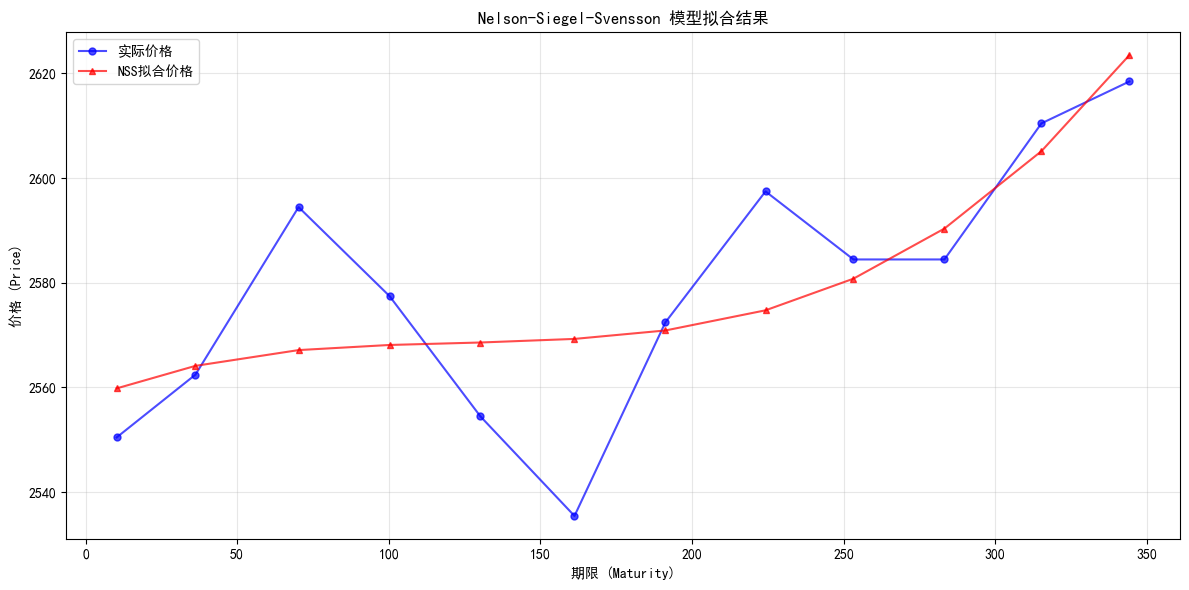

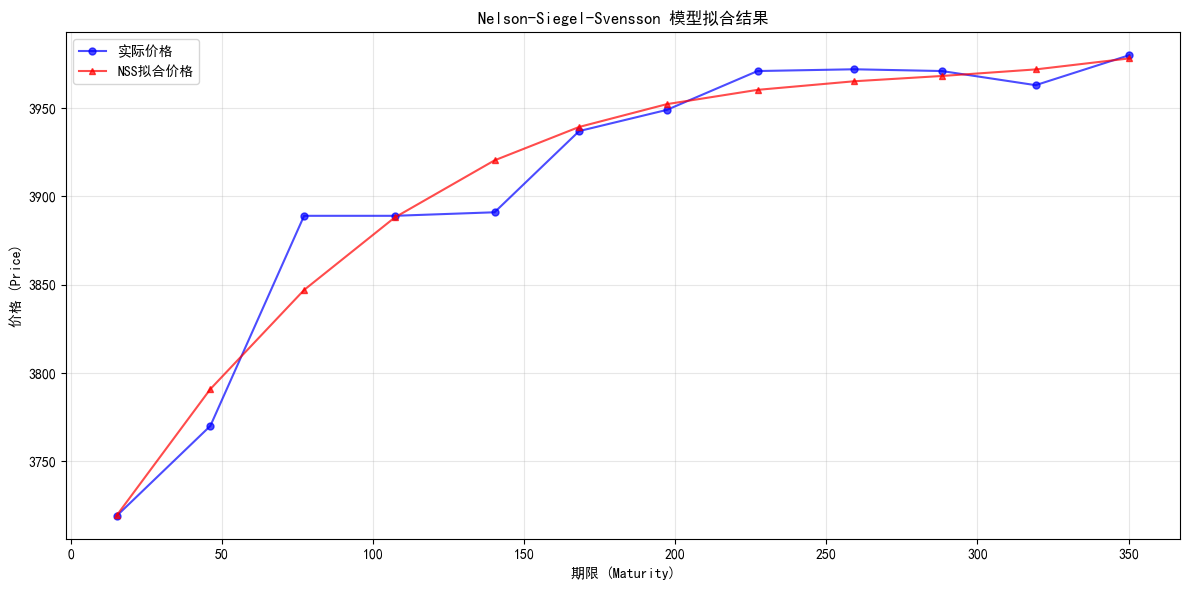

In [16]:
def plot_nss_sampled_rows(row_index):
    def fit_nss_model_for_single_row(
        row_index: int,
        lambda_1: float,
        lambda_2: float,
        price_matrix: pd.DataFrame,
        maturity_matrix: pd.DataFrame
    ) -> dict:
        current_price_row = price_matrix.iloc[row_index].values
        current_maturity_row = maturity_matrix.iloc[row_index].values

        price_loadings_matrix = compute_nelson_siegel_svensson_price_loadings(  # 计算价格载荷矩阵
            lambda_1 = lambda_1,
            lambda_2 = lambda_2,
            maturity_series = current_maturity_row)
        beta_factors = np.linalg.lstsq(
            price_loadings_matrix,
            current_price_row,
            rcond = None)[0]
        fitted_prices = price_loadings_matrix @ beta_factors # 计算拟合价格
        error = np.mean((current_price_row - fitted_prices) ** 2)
        return {
            'actual_prices': current_price_row,
            'fitted_prices': fitted_prices,
            'maturities': current_maturity_row,
            'beta_factors': beta_factors,
            'mse': error,
            'price_loadings_matrix': price_loadings_matrix}

    def plot_nss_fitting_result(result: dict):
        plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 中文+英文备用
        plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块
        plt.figure(figsize=(12, 6))
        plt.plot(result['maturities'], result['actual_prices'], 'bo-', label = '实际价格', alpha = 0.7, markersize = 5)
        plt.plot(result['maturities'], result['fitted_prices'], 'r^-', label = 'NSS拟合价格', alpha = 0.7, markersize = 5)

        plt.xlabel('期限 (Maturity)')
        plt.ylabel('价格 (Price)')
        plt.title('Nelson-Siegel-Svensson 模型拟合结果')
        plt.legend()
        plt.grid(True, alpha = 0.3)
        plt.tight_layout()
        # plt.savefig(fr"C:\Users\dell\Desktop\tmp_fig\{row_index}.png")
        plt.show()
        plt.close()

    result = fit_nss_model_for_single_row(
        row_index = row_index,
        lambda_1 = 0.000034,
        lambda_2 = 0.000001,
        price_matrix = price_matrix,
        maturity_matrix = maturity_matrix)
    plot_nss_fitting_result(result)

for i in range(0, 60001, 60000): plot_nss_sampled_rows(i)

### 3. lambda 网格搜索函数定义

In [17]:
def get_lambda_combination_dataframe(
    lambda_1_range: tuple = (0.000001, 0.1),
    lambda_2_ratio: tuple = (0.001, 0.999),
    cardinality: int = 20,
    logspace: bool = True
) -> pd.DataFrame:

    if logspace == True:
        lambda_range_1 = np.logspace(np.log(lambda_1_range[0]), np.log(lambda_1_range[1]), cardinality, base = np.e) # 自然底数对数尺度采样 lambda
        lambda_ratio_2 = np.logspace(np.log(lambda_2_ratio[0]), np.log(lambda_2_ratio[1]), cardinality, base = np.e)

    if logspace == False:
        lambda_range_1 = np.linspace(lambda_1_range[0], lambda_1_range[1], cardinality)  # 普通线性等距采样 lambda
        lambda_ratio_2 = np.linspace(lambda_2_ratio[0], lambda_2_ratio[1], cardinality)

    lambda_range_1 = lambda_range_1.tolist()
    lambda_ratio_2 = lambda_ratio_2.tolist()

    from itertools import product
    lambda_combination_list = list(product(lambda_range_1, lambda_ratio_2))
    lambda_dict_list = [{
        'lambda_combination_id': f'lambda_combination_{index}',
        'lambda_1': pair[0],
        'lambda_2_ratio': pair[1]
    } for index, pair in enumerate(lambda_combination_list)]
    lambda_combination_dataframe = pd.DataFrame(lambda_dict_list)
    return lambda_combination_dataframe

In [18]:
def get_iterative_combination_row_error(
    lambda_combination_dataframe,
    price_matrix,
    maturity_matrix
) -> pd.DataFrame:

    iterative_combination_row_error_dict = {}
    for index, row in lambda_combination_dataframe.iterrows():
        lambda_combination_id = row['lambda_combination_id']
        lambda_1 = row['lambda_1']
        lambda_2 = row['lambda_2_ratio'] * lambda_1

        current_combination_error_list = []
        for i in range(len(price_matrix)):
            current_price_row = price_matrix.iloc[i].values
            current_maturity_row = maturity_matrix.iloc[i].values

            error = compute_single_row_fitting_error(
                lambda_1 = lambda_1,
                lambda_2 = lambda_2,
                price_vector = current_price_row,
                maturity_vector = current_maturity_row
            )
            current_combination_error_list.append(error)

        # print(lambda_combination_id, lambda_1, lambda_2)
        print(
            f'{lambda_combination_id:24s}'
            f'{float(lambda_1):0>16.13f} '
            f'{float(lambda_2):0>16.13f}   '
            f'error: {sum(current_combination_error_list) / len(current_combination_error_list)}'
        )
        iterative_combination_row_error_dict[f'{lambda_combination_id}'] = current_combination_error_list

    iterative_combination_row_error = pd.DataFrame(iterative_combination_row_error_dict)
    return iterative_combination_row_error

In [19]:
lambda_combination_dataframe = get_lambda_combination_dataframe(lambda_1_range = (0.0001, 10), lambda_2_ratio= (0.000001, 0.999), cardinality = 1, logspace = False)

iterative_combination_row_error = get_iterative_combination_row_error(
    lambda_combination_dataframe = lambda_combination_dataframe,
    price_matrix = price_matrix.iloc[::1000],
    maturity_matrix = maturity_matrix.iloc[::1000]
)
# 注意，本单元格仅用于测试网格搜索函数，不作为最终结果输出
# 为了方便测试，本单元设置 cardinality = 2，只计算 4 个参数组合，确保没有 NaN 值

lambda_combination_0    00.0001000000000 00.0000000001000   error: 710.7082831593319


### 4. 参数空间范围确定

In [23]:
def Mean_Error_Heatmap_by_Lambda_Combinations_plot(
    iterative_combination_row_error: pd.DataFrame,
    lambda_combination_dataframe: pd.DataFrame
):
    iterative_combination_error_mean = iterative_combination_row_error.mean()  # 计算表二每列的均值
    iterative_combination_error_mean = pd.DataFrame({  # 将均值结果转换为 DataFrame
        'lambda_combination_id': iterative_combination_error_mean.index,
        'mean_error': iterative_combination_error_mean.values
    })

    merged_data = pd.merge(  # 将均值与表一合并
        lambda_combination_dataframe,
        iterative_combination_error_mean,
        on = 'lambda_combination_id',
        how = 'left'
    )

    # 重塑数据为热力图需要的矩阵格式
    # 获取 lambda_1 和 lambda_2 的唯一值并排序
    lambda_1_vals = sorted(merged_data['lambda_1'].unique())
    lambda_2_vals = sorted(merged_data['lambda_2_ratio'].unique())
    heatmap_matrix = merged_data.pivot(
        index = 'lambda_1',
        columns = 'lambda_2_ratio',
        values = 'mean_error'
    )

    plt.figure(figsize = (12, 10))
    from matplotlib.colors import LogNorm
    sns.heatmap(
        heatmap_matrix,

        xticklabels = [f"{x:.5f}" for x in lambda_2_vals],
        yticklabels = [f"{x:.5f}" for x in lambda_1_vals],
        # xticklabels = lambda_2_vals,
        # yticklabels = lambda_1_vals,

        cmap = 'viridis',  #  'viridis'  'coolwarm'  'YlOrRd'  'plasma'  'gray'
        norm = LogNorm(  # 对数映射的色带
            vmin = heatmap_matrix.values.min(),
            vmax = heatmap_matrix.values.max()),

        annot = True,  # 是否显示数值
        annot_kws = {"size": 6.5},  # 显式数值的字体大小
        fmt = '.2f',
    )
    plt.title('Mean Error Heatmap by Lambda Combinations', fontsize = 16, fontweight = 'bold')
    plt.xlabel('lambda_2_ratio', fontsize = 14, fontweight = 'bold')
    plt.ylabel('lambda_1', fontsize = 14, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

    print(f"Lambda 1 的范围: {merged_data['lambda_1'].min()} 到 {merged_data['lambda_1'].max()}")
    print(f"Lambda 2 ratio 的范围: {merged_data['lambda_2_ratio'].min()} 到 {merged_data['lambda_2_ratio'].max()}")
    print(f"平均误差的范围: {merged_data['mean_error'].min()} 到 {merged_data['mean_error'].max()}")
    print(f"最小误差组合:")
    best_idx = merged_data['mean_error'].idxmin()
    print(f"  ID: {merged_data.loc[best_idx, 'lambda_combination_id']}")
    print(f"  Lambda 1: {merged_data.loc[best_idx, 'lambda_1']:.12f}")
    print(f"  Lambda 2 ratio: {merged_data.loc[best_idx, 'lambda_2_ratio']:.12f}")
    print(f"  平均误差: {merged_data.loc[best_idx, 'mean_error']}")

In [24]:
def Optimal_Parameter_Combination_Frequency_Heatmap_plot(
    iterative_combination_row_error: pd.DataFrame,
    lambda_combination_dataframe: pd.DataFrame
):
    optimal_counts = iterative_combination_row_error.idxmin(axis = 1)  # 找到每一行中误差最小的列，即最优的 lambda_combination_id
    optimal_counts = optimal_counts.value_counts()  # 统计每个 lambda 组合成为最优参数的次数
    optimal_counts = pd.DataFrame({
        'lambda_combination_id': optimal_counts.index,
        'optimal_count': optimal_counts.values
    })

    # 将统计结果与表一合并
    merged_optimal_data = pd.merge(
        lambda_combination_dataframe,
        optimal_counts,
        on = 'lambda_combination_id',
        how = 'left', )
    merged_optimal_data['optimal_count'] = merged_optimal_data['optimal_count'].fillna(0)  # 将缺失值，表示该组合从未成为最优，填充为 0

    # 重塑数据为热力图需要的矩阵格式
    lambda_1_vals = sorted(merged_optimal_data['lambda_1'].unique())
    lambda_2_vals = sorted(merged_optimal_data['lambda_2_ratio'].unique())
    optimal_heatmap_matrix = merged_optimal_data.pivot(
        index = 'lambda_1',
        columns = 'lambda_2_ratio',
        values = 'optimal_count'
    )

    # 绘制最优参数频数热力图
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 或 ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False  # 避免数学减号显示问题
    plt.figure(figsize = (12, 10))
    sns.heatmap(
        optimal_heatmap_matrix
        .replace(0.0, 0.2),

        xticklabels = [f"{x:.5f}" for x in lambda_2_vals],
        yticklabels = [f"{x:.5f}" for x in lambda_1_vals],
        # xticklabels = lambda_2_vals,
        # yticklabels = lambda_1_vals,

        cmap = 'viridis',  #  'viridis'  'coolwarm'  'YlOrRd'  'plasma'  'gray_r'
        # norm = LogNorm(vmin = 0.1, vmax = optimal_heatmap_matrix.values.max()),  # 对数映射的色带

        annot = True,  # 显示频数值
        annot_kws = {"size": 6.5},
        fmt = '.0f',  # 使用通用格式，不添加小数位
    )
    plt.title('Optimal Parameter Combination Frequency Heatmap', fontsize = 16, fontweight = 'bold')
    plt.xlabel('lambda_2_ratio', fontsize = 14, fontweight = 'bold')
    plt.ylabel('lambda_1', fontsize = 14, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

    total_rows = len(iterative_combination_row_error)
    most_optimal_idx = merged_optimal_data['optimal_count'].idxmax()
    print(f"最频繁成为最优的参数组合:")
    print(f"  ID: {merged_optimal_data.loc[most_optimal_idx, 'lambda_combination_id']}")
    print(f"  Lambda 1: {merged_optimal_data.loc[most_optimal_idx, 'lambda_1']:.12f}")
    print(f"  Lambda 2 ratio: {merged_optimal_data.loc[most_optimal_idx, 'lambda_2_ratio']:.12f}")
    print(f"  成为最优的次数: {merged_optimal_data.loc[most_optimal_idx, 'optimal_count']}")
    print(f"  占总时间点的比例: {merged_optimal_data.loc[most_optimal_idx, 'optimal_count'] / total_rows * 100}%")

    print(f"\n前 n 个最频繁成为最优的参数组合:")
    top_n_optimal = merged_optimal_data.nlargest(5, 'optimal_count')
    for i, (idx, row) in enumerate(top_n_optimal.iterrows(), 1):
        print(f"{i:2d}. ID: {row['lambda_combination_id']:24s}, "
              f"Lambda 1: {row['lambda_1']:.12f}, "
              f"Lambda 2 ratio: {row['lambda_2_ratio']:.12f}, "
              f"频数: {str(row['optimal_count']):8s}, "
              f"占比: {row['optimal_count'] / total_rows * 100:.2f}%")

lambda_combination_0    00.0001000000000 00.0000001000000   error: 414.2186405052271
lambda_combination_1    00.0001000000000 00.0000001438374   error: 487.94563542171585
lambda_combination_2    00.0001000000000 00.0000002068920   error: 476.6620339899017
lambda_combination_3    00.0001000000000 00.0000002975881   error: 458.4849798627698
lambda_combination_4    00.0001000000000 00.0000004280431   error: 465.1162692803702
lambda_combination_5    00.0001000000000 00.0000006156861   error: 473.5113726702389
lambda_combination_6    00.0001000000000 00.0000008855869   error: 474.45103246749983
lambda_combination_7    00.0001000000000 00.0000012738054   error: 472.8234220061291
lambda_combination_8    00.0001000000000 00.0000018322087   error: 471.97230251179616
lambda_combination_9    00.0001000000000 00.0000026354016   error: 472.39788285114133
lambda_combination_10   00.0001000000000 00.0000037906936   error: 472.62355507198714
lambda_combination_11   00.0001000000000 00.0000054524356   

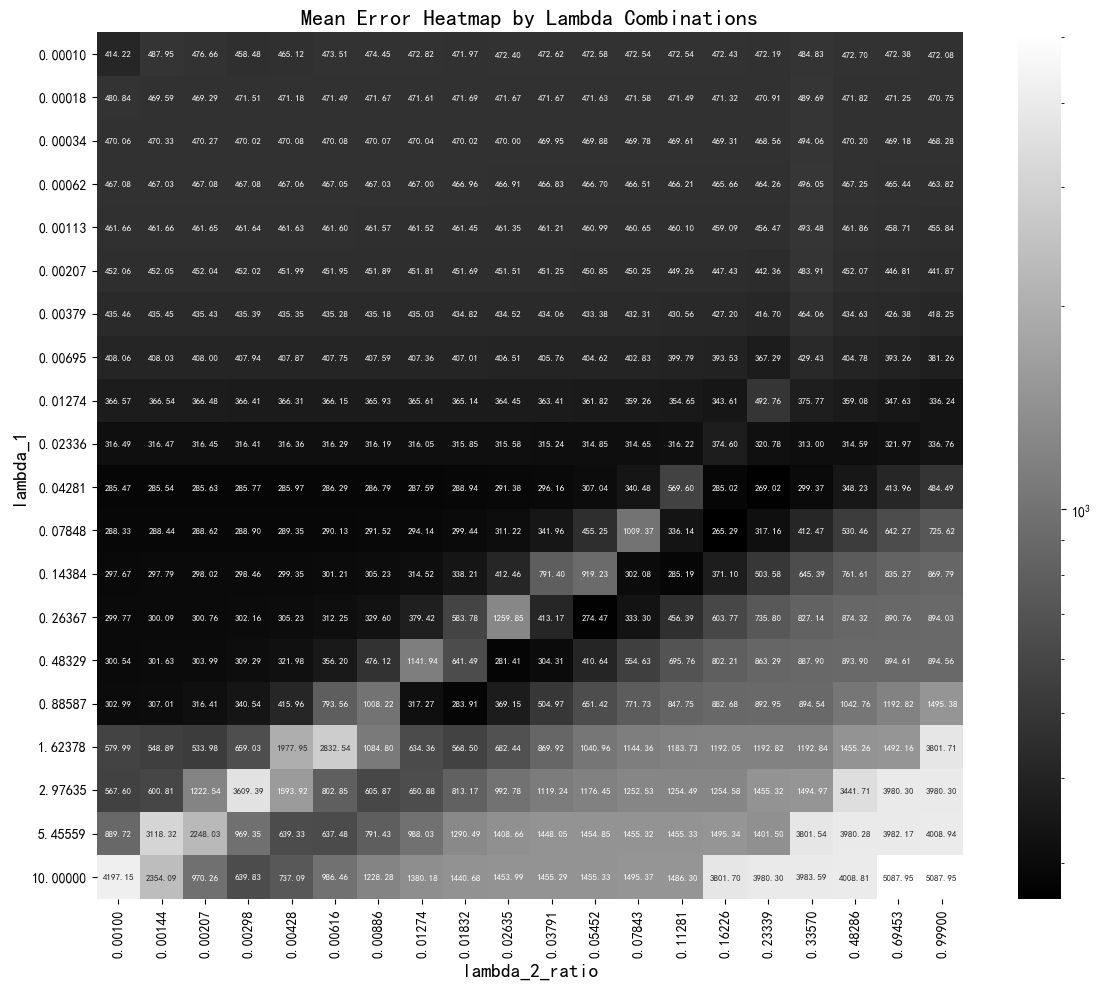

Lambda 1 的范围: 0.00010000000000000014 到 10.000000000000002
Lambda 2 ratio 的范围: 0.0010000000000000007 到 0.999
平均误差的范围: 265.28753630612476 到 5087.946234340731
最小误差组合:
  ID: lambda_combination_234
  Lambda 1: 0.078475997035
  Lambda 2 ratio: 0.162258011462
  平均误差: 265.28753630612476


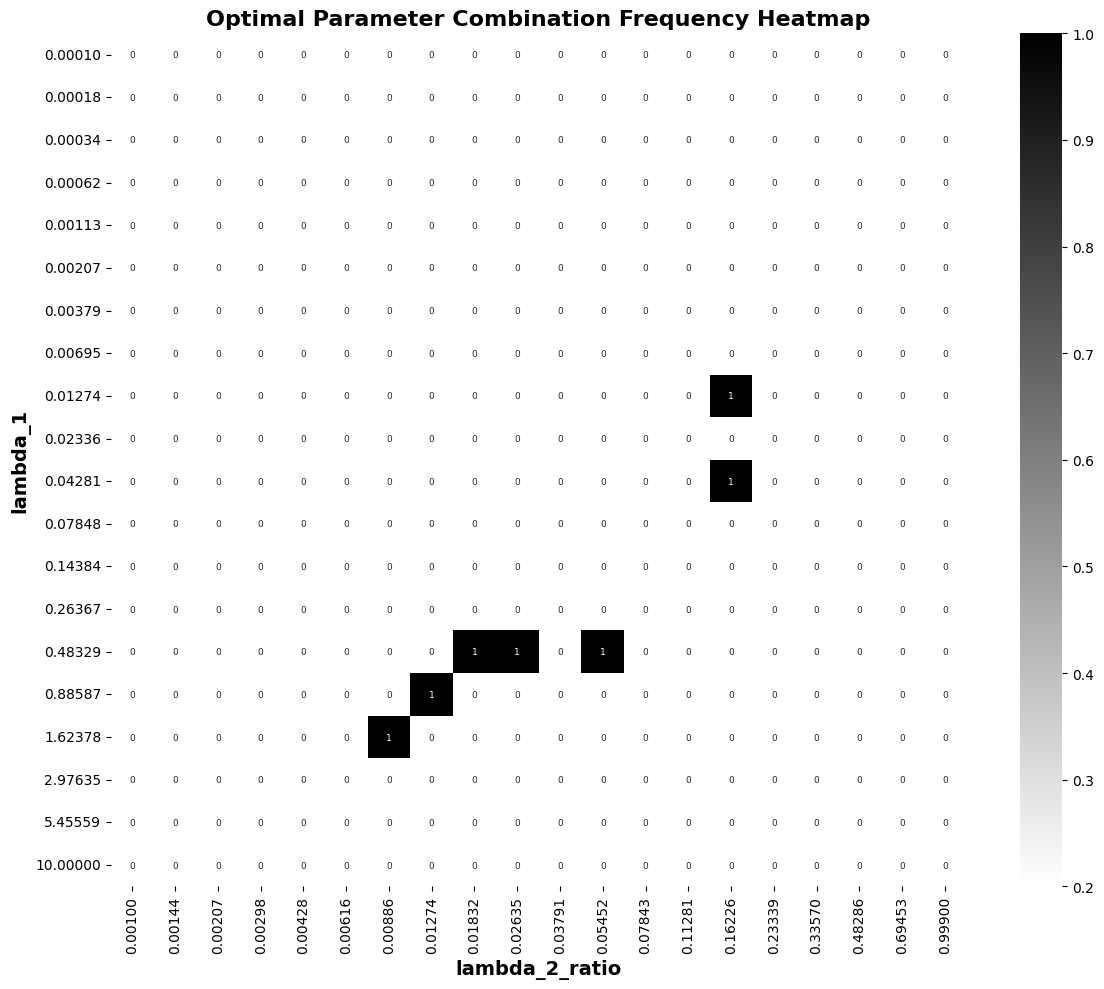

最频繁成为最优的参数组合:
  ID: lambda_combination_174
  Lambda 1: 0.012742749857
  Lambda 2 ratio: 0.162258011462
  成为最优的次数: 1.0
  占总时间点的比例: 14.285714285714285%

前 n 个最频繁成为最优的参数组合:
 1. ID: lambda_combination_174  , Lambda 1: 0.012742749857, Lambda 2 ratio: 0.162258011462, 频数: 1.0     , 占比: 14.29%
 2. ID: lambda_combination_214  , Lambda 1: 0.042813323987, Lambda 2 ratio: 0.162258011462, 频数: 1.0     , 占比: 14.29%
 3. ID: lambda_combination_288  , Lambda 1: 0.483293023857, Lambda 2 ratio: 0.018322087060, 频数: 1.0     , 占比: 14.29%
 4. ID: lambda_combination_289  , Lambda 1: 0.483293023857, Lambda 2 ratio: 0.026354016300, 频数: 1.0     , 占比: 14.29%
 5. ID: lambda_combination_291  , Lambda 1: 0.483293023857, Lambda 2 ratio: 0.054524356137, 频数: 1.0     , 占比: 14.29%


In [24]:
lambda_combination_dataframe = get_lambda_combination_dataframe(lambda_1_range = (0.0001, 10), lambda_2_ratio= (0.001, 0.999), logspace = True)

iterative_combination_row_error = get_iterative_combination_row_error(
    lambda_combination_dataframe = lambda_combination_dataframe,
    price_matrix = price_matrix.iloc[::10000],
    maturity_matrix = maturity_matrix.iloc[::10000]
)

Mean_Error_Heatmap_by_Lambda_Combinations_plot(iterative_combination_row_error, lambda_combination_dataframe)
Optimal_Parameter_Combination_Frequency_Heatmap_plot(iterative_combination_row_error, lambda_combination_dataframe)
# 注意，本单元格仅用于做范围确定，不作为最终结果输出
# 通过绘图查看搜索范围的边界是否出现有效值，若边界处的数据点拟合优度更佳，则需要调整扩大搜索范围

### 5. lambda 网格逐行回归

In [25]:
# 期限结构拟合文件路径 Nelson_Siegel_Svensson_path
Nelson_Siegel_Svensson_path = os.path.join(resample_axis_data_path, f'Nelson_Siegel_Svensson')

# NSS 四因子模型超参数组合路径 lambda_combination_dataframe_path
lambda_combination_dataframe_path = os.path.join(Nelson_Siegel_Svensson_path, 'lambda_combination_dataframe.csv')

# NSS 四因子热启动数据网格搜索结果路径 iterative_combination_row_error_path
iterative_combination_row_error_path = os.path.join(Nelson_Siegel_Svensson_path, 'iterative_combination_row_error.csv')


if os.path.exists(lambda_combination_dataframe_path) and os.path.exists(iterative_combination_row_error_path):
    lambda_combination_dataframe = pd.read_csv(lambda_combination_dataframe_path)
    iterative_combination_row_error = pd.read_csv(iterative_combination_row_error_path)
else:
    lambda_combination_dataframe = get_lambda_combination_dataframe(lambda_1_range = (0.0001, 10), lambda_2_ratio= (0.001, 0.999), logspace = True)
    lambda_combination_dataframe.to_csv(lambda_combination_dataframe_path, index = False)

    iterative_combination_row_error = get_iterative_combination_row_error(
        lambda_combination_dataframe = lambda_combination_dataframe,
        price_matrix = price_matrix[::1],
        maturity_matrix = maturity_matrix[::1],
    )
    iterative_combination_row_error.to_csv(iterative_combination_row_error_path, index = False)

lambda_combination_0    00.0001000000000 00.0000001000000   error: 685.1675798419719
lambda_combination_1    00.0001000000000 00.0000001438374   error: 681.2624753731093
lambda_combination_2    00.0001000000000 00.0000002068920   error: 680.7742216790612
lambda_combination_3    00.0001000000000 00.0000002975881   error: 682.1865487704989
lambda_combination_4    00.0001000000000 00.0000004280431   error: 683.7142585655678
lambda_combination_5    00.0001000000000 00.0000006156861   error: 683.6579895097615
lambda_combination_6    00.0001000000000 00.0000008855869   error: 684.8719700466374
lambda_combination_7    00.0001000000000 00.0000012738054   error: 685.1090895763132
lambda_combination_8    00.0001000000000 00.0000018322087   error: 686.47871039695
lambda_combination_9    00.0001000000000 00.0000026354016   error: 685.5019473714781
lambda_combination_10   00.0001000000000 00.0000037906936   error: 686.0524429290351
lambda_combination_11   00.0001000000000 00.0000054524356   error: 

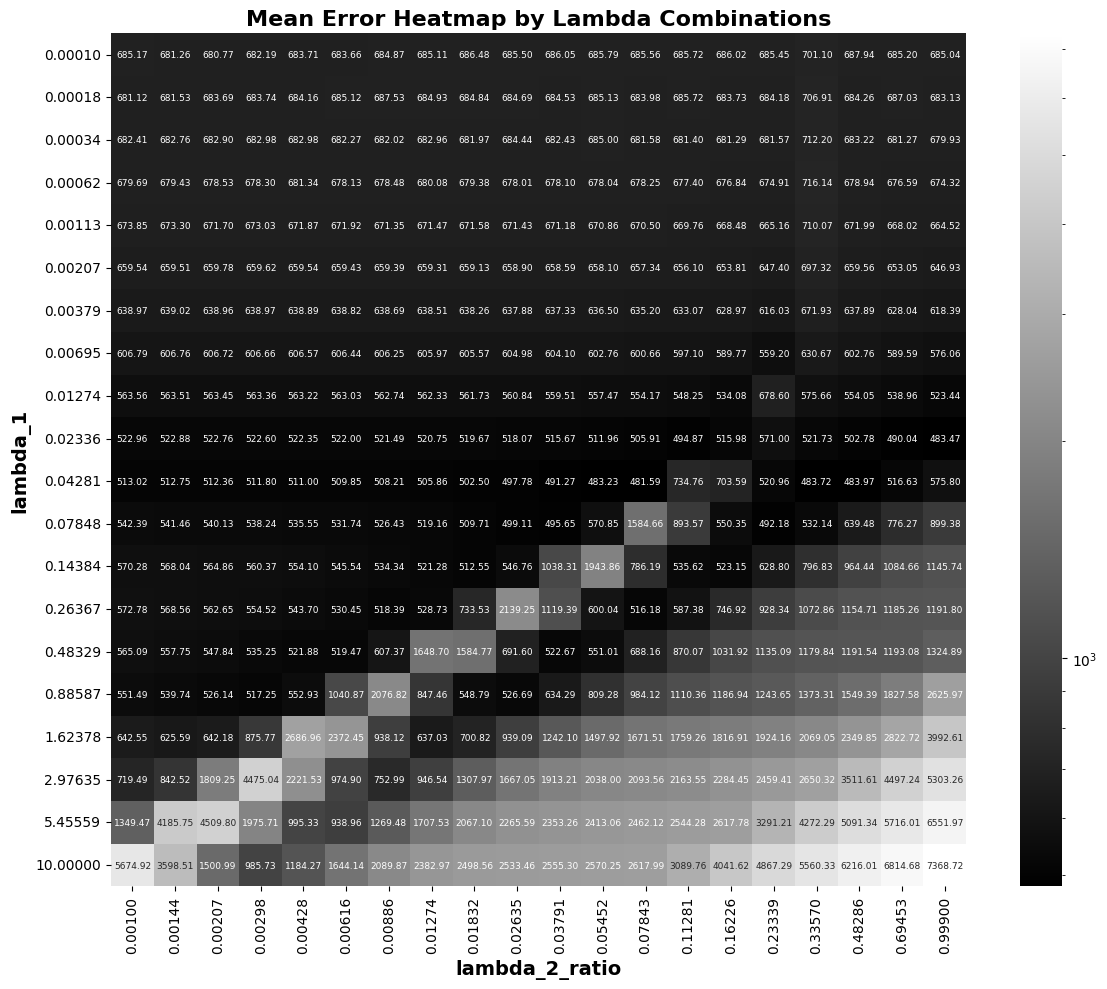

Lambda 1 的范围: 0.00010000000000000014 到 10.000000000000002
Lambda 2 ratio 的范围: 0.0010000000000000007 到 0.999
平均误差的范围: 481.5938172925316 到 7368.724627477206
最小误差组合:
  ID: lambda_combination_212
  Lambda 1: 0.042813323987
  Lambda 2 ratio: 0.078426424113
  平均误差: 481.5938172925316


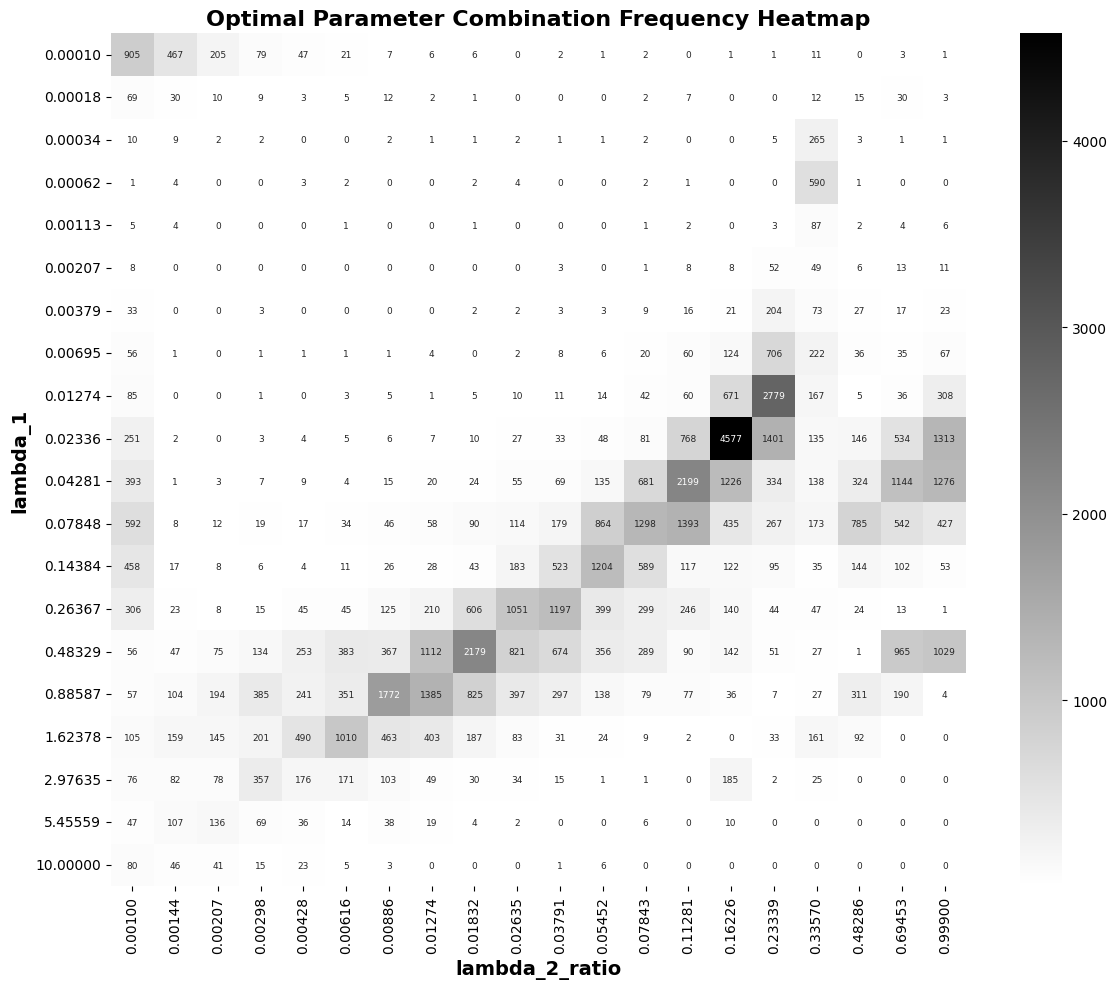

最频繁成为最优的参数组合:
  ID: lambda_combination_194
  Lambda 1: 0.023357214691
  Lambda 2 ratio: 0.162258011462
  成为最优的次数: 4577.0
  占总时间点的比例: 7.134840218238503%

前 n 个最频繁成为最优的参数组合:
 1. ID: lambda_combination_194  , Lambda 1: 0.023357214691, Lambda 2 ratio: 0.162258011462, 频数: 4577.0  , 占比: 7.13%
 2. ID: lambda_combination_175  , Lambda 1: 0.012742749857, Lambda 2 ratio: 0.233387728427, 频数: 2779.0  , 占比: 4.33%
 3. ID: lambda_combination_213  , Lambda 1: 0.042813323987, Lambda 2 ratio: 0.112806540691, 频数: 2199.0  , 占比: 3.43%
 4. ID: lambda_combination_288  , Lambda 1: 0.483293023857, Lambda 2 ratio: 0.018322087060, 频数: 2179.0  , 占比: 3.40%
 5. ID: lambda_combination_306  , Lambda 1: 0.885866790410, Lambda 2 ratio: 0.008855869472, 频数: 1772.0  , 占比: 2.76%


In [26]:
Mean_Error_Heatmap_by_Lambda_Combinations_plot(iterative_combination_row_error, lambda_combination_dataframe)
Optimal_Parameter_Combination_Frequency_Heatmap_plot(iterative_combination_row_error, lambda_combination_dataframe)